# Model 1 — Local Retrain (M06, phases B–C)

Retrains the title→skills model on the **local** corpus that already exists in
`careerlens.lang-uk-job` (141,897 raw postings, HuggingFace field names), instead of
the unreachable historical training set. The chain: corpus EDA → balanced sample →
checkpointed SkillNer extraction → skills-over-time EDA → **marked** 2023→2026
augmentation → `train.py` retrain → new `model.joblib` verification.

**Honesty contract:** the real corpus ends mid-2023. Every 2023H2–2026H1 record is
synthetic, generated by `augment_2026.py` from curated per-role market lists
(`market_2026_skills.py`), and carries `source='augmented-2026'`. Methodology is
documented in `docs/final-sprint/outputs/06-model1-report.md`.

Runs top-to-bottom given Mongo on `localhost:27017`. Long steps (extraction) are
checkpointed: re-running never re-extracts a document.

In [1]:
import os, sys, subprocess, warnings
from collections import Counter, defaultdict
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt
from pymongo import MongoClient

warnings.filterwarnings('ignore')
os.environ.setdefault('MONGO_URI', 'mongodb://localhost:27017/careerlens')
sys.path.insert(0, os.path.abspath('.'))          # run from ds/model
from lang_uk_mapping import map_primary_keyword, MIN_DESCRIPTION_LEN

client = MongoClient(os.environ['MONGO_URI'])
db = client['careerlens']
RAW, SAMPLE, SKILLS, AUG = 'lang-uk-job', 'lang-uk-job-sample', 'lang-uk-job-skills', 'augmented-2026'
print({c: db[c].estimated_document_count() for c in (RAW, SAMPLE, SKILLS, AUG)})

{'lang-uk-job': 141897, 'lang-uk-job-sample': 41745, 'lang-uk-job-skills': 41745, 'augmented-2026': 10800}


## 1. Raw corpus overview

The raw dump keeps the original Djinni/HuggingFace fields (`Position`,
`Primary Keyword`, `Long Description`, `Published`). `lang_uk_mapping.py` — the same
module the HF import path uses — maps `Primary Keyword` to our canonical titles, so
the notebook never invents a second mapping.

In [2]:
kw_counts = {r['_id']: r['n'] for r in db[RAW].aggregate([
    {'$group': {'_id': '$Primary Keyword', 'n': {'$sum': 1}}}])}
rows = []
for kw, n in kw_counts.items():
    rows.append({'primary_keyword': kw, 'canonical': map_primary_keyword(kw), 'postings': n})
kw_df = pd.DataFrame(rows)
mapped = (kw_df.dropna(subset=['canonical'])
          .groupby('canonical')['postings'].sum().sort_values(ascending=False))
print(f"total raw: {kw_df.postings.sum():,} | mapped: {mapped.sum():,} | "
      f"dropped (non-tech/other): {kw_df[kw_df.canonical.isna()].postings.sum():,}")
mapped.to_frame('postings')

total raw: 141,897 | mapped: 106,979 | dropped (non-tech/other): 34,918


,postings
canonical,
Backend Developer,22308
Frontend Developer,17904
Software Engineer,14239
QA Automation Engineer,13821
DevOps Engineer,9673
Java Developer,8712
Product Manager,6557
UX Designer,4020
C++ Developer,3743


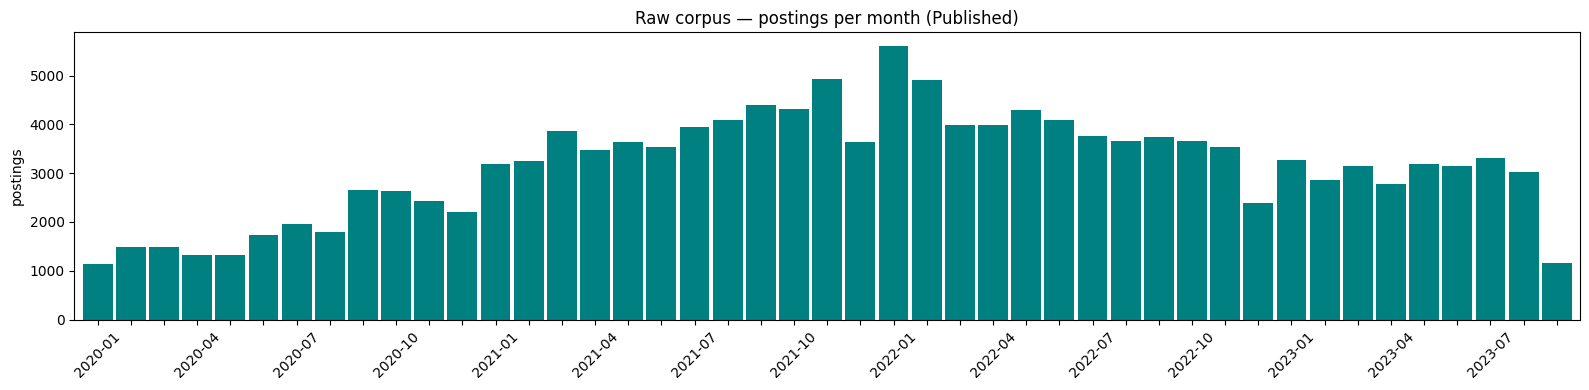

Corpus time span: 2020-01 → 2023-09


In [3]:
monthly = pd.DataFrame(list(db[RAW].aggregate([
    {'$project': {'m': {'$substr': ['$Published', 0, 7]}}},
    {'$group': {'_id': '$m', 'n': {'$sum': 1}}}, {'$sort': {'_id': 1}}])))
monthly = monthly[monthly['_id'].str.match(r'20\d\d-\d\d')]
ax = monthly.set_index('_id')['n'].plot(kind='bar', figsize=(16, 4), color='teal', width=0.9)
ax.set_title('Raw corpus — postings per month (Published)'); ax.set_xlabel(''); ax.set_ylabel('postings')
ax.set_xticklabels([t.get_text() if i % 3 == 0 else '' for i, t in enumerate(ax.get_xticklabels())], rotation=45)
plt.tight_layout(); plt.show()
print('Corpus time span:', monthly['_id'].min(), '→', monthly['_id'].max())

## 2. Balanced sample + checkpointed SkillNer extraction

`sample_local_corpus.py` normalizes the raw fields (via `lang_uk_mapping`) and
balances per role (cap 4,000, seed 42) into `lang-uk-job-sample`.
`extract_skills_parallel.py` shards the pending docs across worker processes; the
`extracted: true` checkpoint means a document is **never** extracted twice and an
interrupted run resumes where it stopped.

In [4]:
sample_n = db[SAMPLE].estimated_document_count()
pending = db[SAMPLE].count_documents({'extracted': {'$ne': True}})
print(f"sample: {sample_n:,} docs | pending extraction: {pending:,}")
if sample_n == 0:
    print('Building sample ...')
    subprocess.run([sys.executable, 'sample_local_corpus.py'], check=True)
if pending > 0:
    if os.getenv('RUN_EXTRACTION') == '1':
        subprocess.run([sys.executable, 'extract_skills_parallel.py'], check=True)
    else:
        print('>> Extraction incomplete. Run:  WORKERS=8 python extract_skills_parallel.py')
        print('>> (checkpointed - safe to stop/resume; ~2.3s/doc/worker)')
per_role = pd.DataFrame(list(db[SAMPLE].aggregate([
    {'$group': {'_id': '$og_title', 'sampled': {'$sum': 1},
                'extracted': {'$sum': {'$cond': ['$extracted', 1, 0]}}}},
    {'$sort': {'sampled': -1}}]))).rename(columns={'_id': 'role'})
per_role

sample: 41,745 docs | pending extraction: 0


,role,sampled,extracted
0,Product Manager,4000,4000
1,Backend Developer,4000,4000
2,DevOps Engineer,4000,4000
3,Frontend Developer,4000,4000
4,QA Automation Engineer,4000,4000
5,Software Engineer,4000,4000
6,UX Designer,4000,4000
7,Java Developer,4000,4000
8,C++ Developer,3743,3743
9,Data Engineer,2910,2910


## 3. EDA — skills × role × time (real data, 2020–2023)

Which skills each role's market demands, and how skill prevalence moves over time
inside the real corpus. Skills are taken from SkillNer full matches plus
high-confidence (≥0.9) n-gram matches, one count per document.

In [5]:
def doc_skills(doc):
    seen = set()
    sk = doc.get('skills') or {}
    for m in sk.get('full_matches', []):
        v = (m.get('doc_node_value') or '').lower().strip()
        if len(v) >= 3: seen.add(v)
    for m in sk.get('ngram_matches', []):
        v = (m.get('doc_node_value') or '').lower().strip()
        if len(v) >= 3 and float(m.get('score', 0)) >= 0.9: seen.add(v)
    return seen

records = []
for doc in db[SKILLS].find({}, {'og_title': 1, 'skills': 1, 'datePosted': 1}):
    dt = doc.get('datePosted')
    month = dt.strftime('%Y-%m') if isinstance(dt, datetime) else None
    for s in doc_skills(doc):
        records.append((doc['og_title'], s, month))
eda = pd.DataFrame(records, columns=['role', 'skill', 'month'])
n_docs = db[SKILLS].estimated_document_count()
print(f"{n_docs:,} extracted docs → {len(eda):,} (doc, skill) observations, "
      f"{eda.skill.nunique():,} distinct skills")

41,745 extracted docs → 773,696 (doc, skill) observations, 21,103 distinct skills


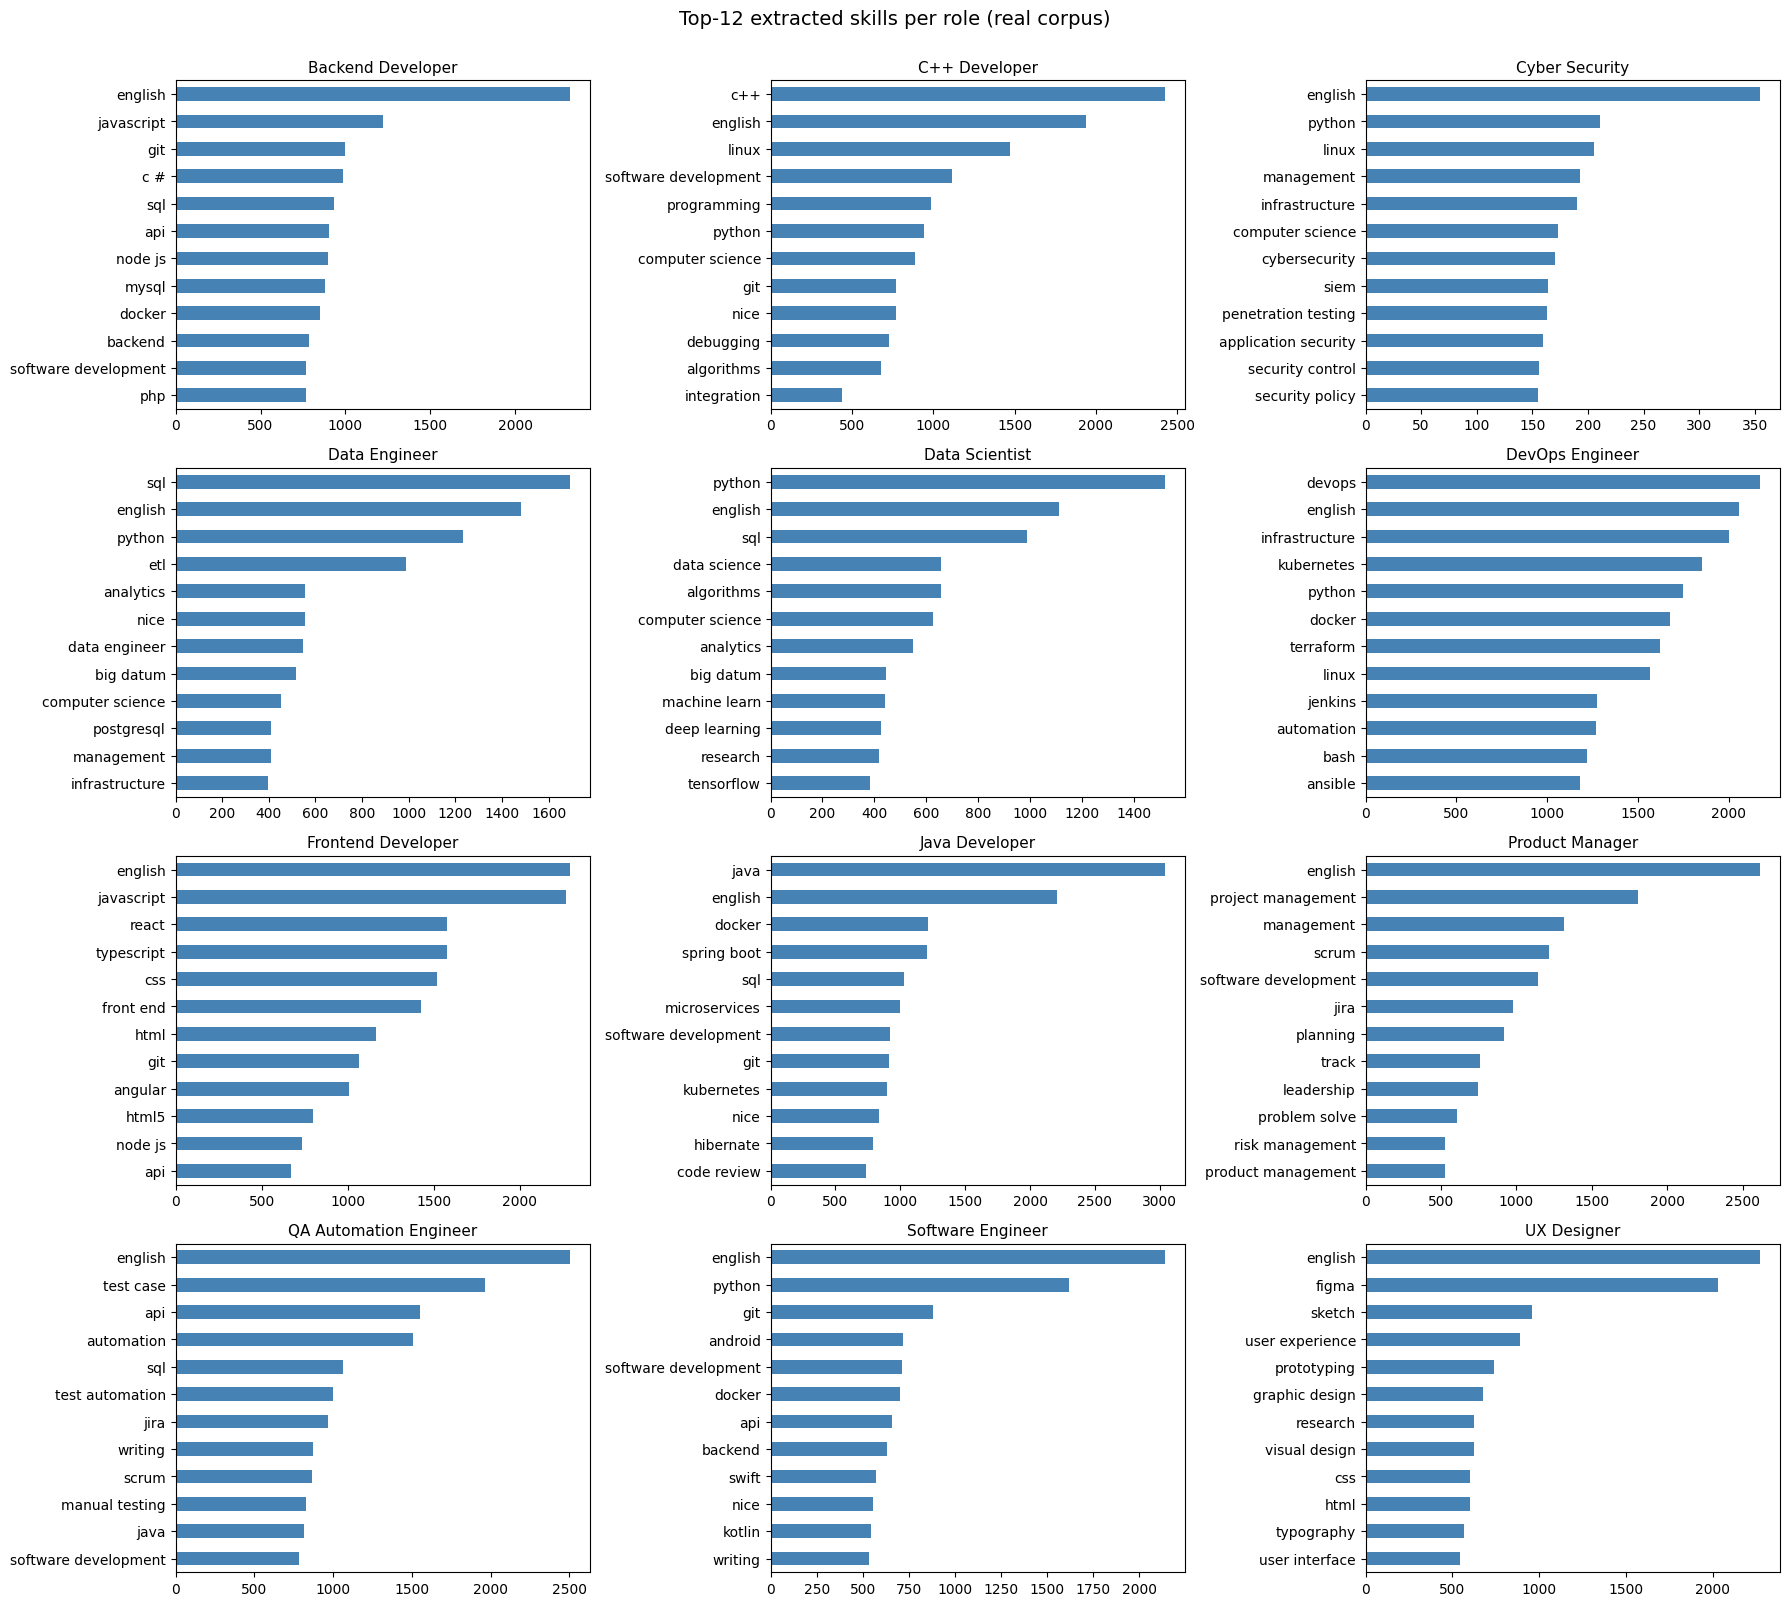

In [6]:
top_by_role = (eda.groupby(['role', 'skill']).size().rename('docs').reset_index()
               .sort_values(['role', 'docs'], ascending=[True, False])
               .groupby('role').head(12))
roles = sorted(top_by_role.role.unique())
nrows = (len(roles) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(18, 4 * nrows))
for ax, role in zip(axes.flat, roles):
    g = top_by_role[top_by_role.role == role].set_index('skill')['docs'].sort_values()
    g.plot(kind='barh', ax=ax, color='steelblue'); ax.set_title(role, fontsize=11); ax.set_ylabel('')
for ax in axes.flat[len(roles):]: ax.axis('off')
plt.suptitle('Top-12 extracted skills per role (real corpus)', y=1.001, fontsize=14)
plt.tight_layout(); plt.show()

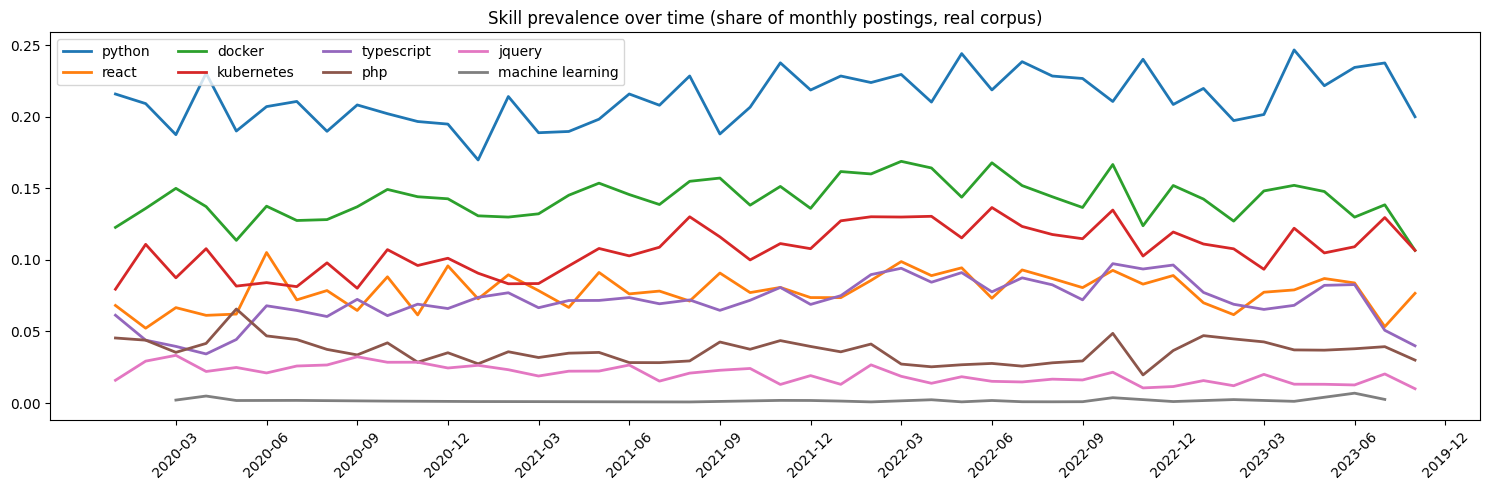

In [7]:
doc_month = pd.DataFrame(
    [(doc['og_title'], doc['datePosted'].strftime('%Y-%m'))
     for doc in db[SKILLS].find({'datePosted': {'$ne': None}}, {'og_title': 1, 'datePosted': 1})
     if isinstance(doc.get('datePosted'), datetime)],
    columns=['role', 'month'])
totals = doc_month.groupby('month').size()
WATCH = ['python', 'react', 'docker', 'kubernetes', 'typescript', 'php', 'jquery', 'machine learning']
plt.figure(figsize=(15, 5))
for sk in WATCH:
    m = (eda[eda.skill == sk].dropna(subset=['month']).groupby('month').size() / totals).dropna()
    m = m[m.index >= '2020-01']
    if len(m) > 3: plt.plot(m.index, m.values, label=sk, linewidth=2)
plt.legend(ncol=4); plt.title('Skill prevalence over time (share of monthly postings, real corpus)')
plt.xticks([m for i, m in enumerate(sorted(totals.index)) if i % 3 == 0], rotation=45)
plt.tight_layout(); plt.show()

In [8]:
from scipy import stats as sstats
moves = []
for sk, g in eda.dropna(subset=['month']).groupby('skill'):
    if len(g) < 200: continue
    share = (g.groupby('month').size() / totals).dropna()
    if len(share) < 12: continue
    x = pd.to_datetime(share.index).map(lambda d: d.year * 12 + d.month)
    slope, _, r, p, _ = sstats.linregress(x, share.values)
    moves.append({'skill': sk, 'slope_per_month': slope, 'r': r, 'p': p, 'docs': len(g)})
mv = pd.DataFrame(moves).query('p < 0.05')
print('Real-corpus movers 2020-2023 (significant slope):')
display(mv.nlargest(10, 'slope_per_month')[['skill', 'slope_per_month', 'docs']])
display(mv.nsmallest(10, 'slope_per_month')[['skill', 'slope_per_month', 'docs']])

Real-corpus movers 2020-2023 (significant slope):


,skill,slope_per_month,docs
226,figma,0.001334,2345
193,devops,0.001084,4382
410,problem solve,0.001074,3983
574,terraform,0.000997,2322
113,collaboration,0.000955,3366
440,python,0.000764,8925
308,kubernetes,0.000735,4582
241,gcp,0.000707,1822
150,data engineer,0.000693,809
367,nice,0.000690,6481


,skill,slope_per_month,docs
293,javascript,-0.001227,5987
217,english,-0.000956,23308
295,jenkins,-0.000679,3352
244,git,-0.000614,6979
360,mysql,-0.000592,3230
378,oop,-0.000591,2519
264,html5,-0.000586,1406
137,css,-0.000578,3658
313,linux,-0.000547,5331
537,sql,-0.000518,7182


## 4. 2023→2026 augmentation (marked synthetic)

`augment_2026.py` extends each role's timeline through 2026H1: base skills are
sampled from the role's **real** distribution above, fading skills down-weighted,
and the curated emerging skills (`market_2026_skills.py`) injected on a linear
half-year prevalence ramp. Every record is marked `source='augmented-2026'`.

In [9]:
r = subprocess.run([sys.executable, 'augment_2026.py'], capture_output=True, text=True)
print(r.stdout[-3000:]); assert r.returncode == 0, r.stderr[-2000:]

Base pools from lang-uk-job-skills (41,745 real docs)
  Backend Developer: pool=50 top5=['english', 'javascript', 'git', 'c #', 'sql']
    2026H1 docs with emerging skills: 147/150
  C++ Developer: pool=50 top5=['c++', 'english', 'linux', 'software development', 'programming']
    2026H1 docs with emerging skills: 105/150
  Cyber Security: pool=50 top5=['english', 'python', 'linux', 'management', 'infrastructure']
    2026H1 docs with emerging skills: 127/150
  Data Engineer: pool=50 top5=['sql', 'english', 'python', 'etl', 'analytics']
    2026H1 docs with emerging skills: 136/150
  Data Scientist: pool=50 top5=['python', 'english', 'sql', 'data science', 'algorithms']
    2026H1 docs with emerging skills: 149/150
  DevOps Engineer: pool=50 top5=['devops', 'english', 'infrastructure', 'kubernetes', 'python']
    2026H1 docs with emerging skills: 148/150
  Frontend Developer: pool=50 top5=['english', 'javascript', 'react', 'typescript', 'css']
    2026H1 docs with emerging skills: 131/

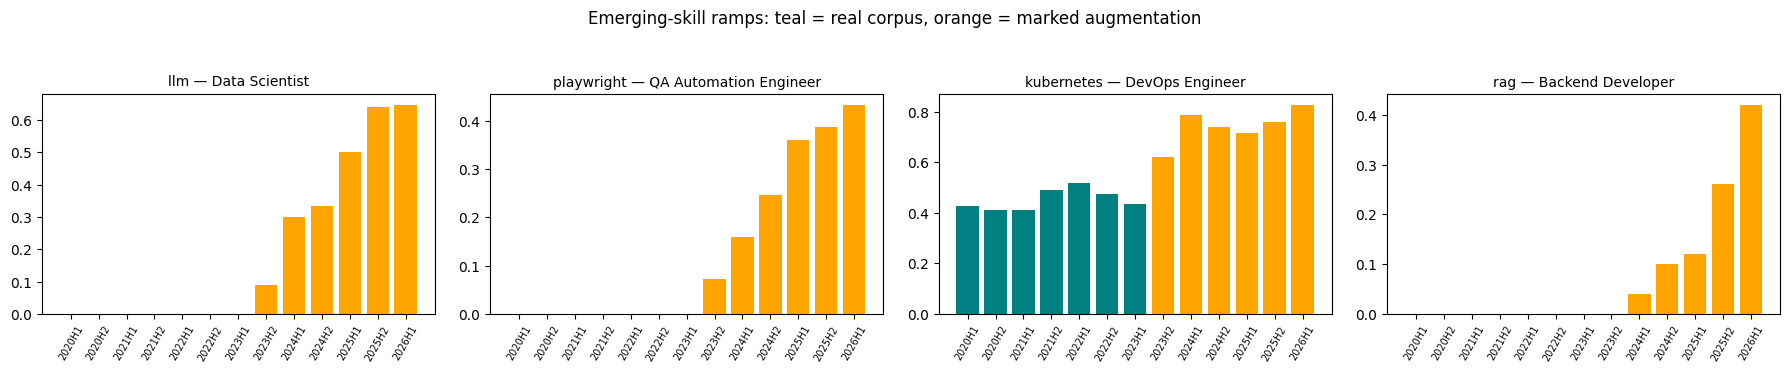

In [10]:
def half(dt): return f"{dt.year}H{1 if dt.month <= 6 else 2}"
CHECKS = [('Data Scientist', 'llm'), ('QA Automation Engineer', 'playwright'),
          ('DevOps Engineer', 'kubernetes'), ('Backend Developer', 'rag')]
fig, axes = plt.subplots(1, len(CHECKS), figsize=(18, 3.5))
for ax, (role, skill) in zip(axes, CHECKS):
    per, tot = Counter(), Counter()
    for coll in (SKILLS, AUG):
        for doc in db[coll].find({'og_title': role, 'datePosted': {'$ne': None}}, {'skills': 1, 'datePosted': 1}):
            if not isinstance(doc.get('datePosted'), datetime): continue
            h = half(doc['datePosted']); tot[h] += 1
            if skill in doc_skills(doc): per[h] += 1
    hs = sorted(h for h in tot if h >= '2020H1')
    ax.bar(hs, [per[h] / tot[h] for h in hs], color=['teal' if h < '2023H2' else 'orange' for h in hs])
    ax.set_title(f"{skill} — {role}", fontsize=10); ax.tick_params(axis='x', rotation=60, labelsize=7)
plt.suptitle('Emerging-skill ramps: teal = real corpus, orange = marked augmentation', y=1.05)
plt.tight_layout(); plt.show()

## 5. Retrain (`train.py` — single source of truth)

The notebook does **not** reimplement training; it runs `train.py` with the corpus
pointed at the local collections. Two time constants are retuned via env (they are
env-configurable by design): the defaults `RECENCY_HALF_LIFE_DAYS=14` /
`TREND_WINDOW_DAYS=7` were built for a continuously-scraped corpus anchored to
"now" — against a 6-year corpus they would annihilate all history
(weight of a 2023 posting ≈ 0.5^75 ≈ 10⁻²³). We use **365/365**: postings decay by
half per year, "recent" = the last year.

`model.joblib` is backed up first; `train.py` writes a versioned snapshot and
promotes to `model.joblib` only if the promotion gate passes.

In [11]:
import shutil
if os.path.exists('model.joblib'):
    bak = f"model.joblib.bak-{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    if not any(f.startswith('model.joblib.bak-') for f in os.listdir('.')):
        shutil.copy2('model.joblib', bak); print('backup:', bak)
    else:
        print('backup already exists:', [f for f in os.listdir('.') if f.startswith('model.joblib.bak-')])
env = {**os.environ,
       'MONGO_URI': 'mongodb://localhost:27017/careerlens',
       'SOURCE_WEIGHTS': 'lang-uk-job-skills:1.0,augmented-2026:1.0',
       'RECENCY_HALF_LIFE_DAYS': '365', 'TREND_WINDOW_DAYS': '365',
       'PYTHONIOENCODING': 'utf-8'}
r = subprocess.run([sys.executable, 'train.py'], capture_output=True, text=True, env=env)
print(r.stdout[-4000:]); assert r.returncode == 0, (r.stdout[-2000:], r.stderr[-2000:])

backup already exists: ['model.joblib.bak-20260728']


skills)
     0  (w=   0.0)  Embedded Engineer  (0 unique skills)
     0  (w=   0.0)  Fullstack Engineer  (0 unique skills)
     0  (w=   0.0)  Cloud Security  (0 unique skills)
  4563  (w= 543.9)  C++ Developer  (5890 unique skills)
     0  (w=   0.0)  Distributed Systems Engineer  (0 unique skills)
     0  (w=   0.0)  Security Operations  (0 unique skills)
  4716  (w= 561.0)  UX Designer  (4841 unique skills)
     0  (w=   0.0)  Security Architect  (0 unique skills)
     0  (w=   0.0)  Firmware Engineer  (0 unique skills)
     0  (w=   0.0)  Machine Learning Engineer  (0 unique skills)
     0  (w=   0.0)  AI Researcher  (0 unique skills)
     0  (w=   0.0)  Malware Researcher  (0 unique skills)
     0  (w=   0.0)  Threat Analyst  (0 unique skills)
     0  (w=   0.0)  Security Researcher  (0 unique skills)
     0  (w=   0.0)  Driver Developer  (0 unique skills)
     0  (w=   0.0)  Solutions Architect  (0 unique skills)
     0  (w=   0.0)  NLP Engineer  (0 unique skills)
     0  (w=   0

## 6. New model verification

Loads the newly written `model.joblib`, checks: per-role record counts, trend-label
distribution (must not be degenerate), presence of 2024–2026 skills, and the top-5
skills each role will actually serve (through `select_display_skills`, i.e. including
the phase-A commonness filter).

In [12]:
import joblib
art = joblib.load('model.joblib')
fm = art['feature_matrix']          # canonical role -> skill -> features
print('trained_at:', art['trained_at'])
trend_counts = Counter(f.get('trend', '?') for role in fm.values() for f in role.values())
print('trend distribution:', dict(trend_counts))
populated = {r: len(v) for r, v in fm.items() if v}
print(f"roles with skills: {len(populated)} | total (role, skill) rows: {sum(populated.values()):,}")

trained_at: 20260728_005411
trend distribution: {'stable': 66085, 'rising': 163, 'falling': 9}
roles with skills: 12 | total (role, skill) rows: 66,257


In [13]:
from skill_schema import select_display_skills, compute_role_counts
role_counts = compute_role_counts(fm)
rows = []
for role in sorted(populated):
    top = select_display_skills(fm[role], pool_size=10, display_count=5,
                                role_counts=role_counts)
    rows.append({'role': role,
                 'top5_served': ', '.join(s['skill'] for s in top),
                 'records': len(fm[role])})
pd.set_option('display.max_colwidth', 120)
pd.DataFrame(rows)

,role,top5_served,records
0,Backend Developer,"kubernetes, javascript, docker, node js, git",5642
1,C++ Developer,"python, software development, git, programming, computer science",5890
2,Cyber Security,"cloud security, english, management, python, penetration testing",3217
3,Data Engineer,"snowflake, airflow, data engineer, python, big datum",5801
4,Data Scientist,"llm, generative ai, pytorch, data science, english",4974
5,DevOps Engineer,"kubernetes, terraform, python, bash, devops",6598
6,Frontend Developer,"typescript, react, node js, html, css",5306
7,Java Developer,"spring boot, kubernetes, microservices, sql, software development",6059
8,Product Manager,"scrum, software development, jira, planning, management",6115
9,QA Automation Engineer,"manual testing, test plans, automation, api, scrum",5751


In [14]:
from market_2026_skills import EMERGING_SKILLS
missing = {}
for role, skills in EMERGING_SKILLS.items():
    have = fm.get(role, {})
    miss = [s for s in skills if s not in have]
    if miss: missing[role] = miss
print('emerging skills missing from model:', missing or 'NONE - all present')

emerging skills missing from model: NONE - all present


## 7. Wrap-up

* New `model.joblib` trained on the balanced real sample (2020–2023) + marked
  synthetic 2023H2–2026H1 continuation; versioned snapshot + run recorded in
  `model_runs`.
* Serving verification (DS server restart, `/title/skills`, trend endpoint, the
  Stable/Trending slider via Playwright) is executed outside the notebook — results
  in `docs/final-sprint/outputs/06-model1-report.md`.
* To extend extraction beyond the balanced sample later: enlarge the sample cap and
  re-run `extract_skills_parallel.py` — the checkpoint skips everything done.